In [2]:
# AdaBoost on Income Dataset

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import AdaBoostClassifier

# Load dataset
df = pd.read_csv("income.csv")

# Display basic info
print("Dataset shape:", df.shape)

# Handle missing values (if any)
df = df.dropna()

# Encode categorical variables
label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Split features and target
X = df.drop("income_level", axis=1)   # target column assumed as 'income_level'
y = df["income_level"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 1. AdaBoost with n_estimators = 10
# -------------------------------
model_10 = AdaBoostClassifier(n_estimators=10, random_state=42)
model_10.fit(X_train, y_train)

y_pred_10 = model_10.predict(X_test)
score_10 = accuracy_score(y_test, y_pred_10)

print("\nAccuracy with 10 estimators:", score_10)

# -------------------------------
# 2. Fine-tuning n_estimators
# -------------------------------
estimators_range = [10, 50, 100, 150, 200]
best_score = 0
best_n = 0

print("\nTuning results:")

for n in estimators_range:
    model = AdaBoostClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    print(f"n_estimators = {n}, Accuracy = {score}")

    if score > best_score:
        best_score = score
        best_n = n

print("\nBest score:", best_score)
print("Best number of estimators:", best_n)


Dataset shape: (48842, 7)

Accuracy with 10 estimators: 0.8182004299314157

Tuning results:
n_estimators = 10, Accuracy = 0.8182004299314157
n_estimators = 50, Accuracy = 0.8327362063670796
n_estimators = 100, Accuracy = 0.8328385709898659
n_estimators = 150, Accuracy = 0.8329409356126523
n_estimators = 200, Accuracy = 0.8332480294810114

Best score: 0.8332480294810114
Best number of estimators: 200


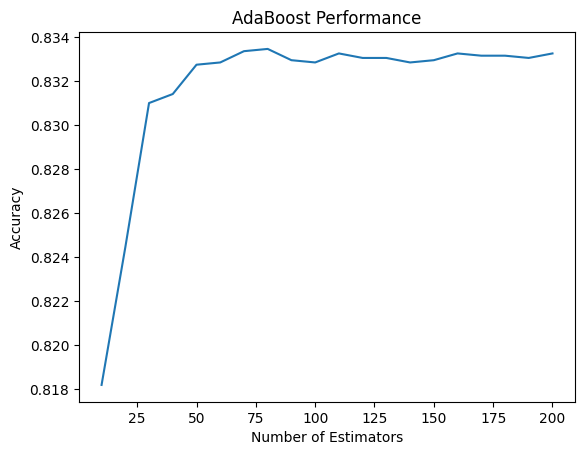

In [3]:
import matplotlib.pyplot as plt

scores = []
for n in range(10, 201, 10):
    model = AdaBoostClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(range(10, 201, 10), scores)
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost Performance")
plt.show()